Codebase

In [15]:
#Block 1

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define dataset paths
train_dir = '/kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train'
test_dir = '/kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Test'

# Get class names (folder names)
class_names = sorted(os.listdir(train_dir))
num_classes = len(class_names)

# Create label mapping
label_map = {i: class_name for i, class_name in enumerate(class_names)}
print("Class mapping:")
for i, class_name in label_map.items():
    print(f"{i}: {class_name}")

# Create DataFrames for train and test
def create_dataframe(directory):
    data = []
    for class_label, class_name in enumerate(class_names):
        class_dir = os.path.join(directory, class_name)
        for filename in os.listdir(class_dir):
            if filename.endswith('.jpg'):
                image_path = os.path.join(class_dir, filename)
                data.append({'image_path': image_path, 'label': class_label})
    return pd.DataFrame(data)

train_df = create_dataframe(train_dir)
test_df = create_dataframe(test_dir)

# Combine for EDA
df = pd.concat([train_df, test_df], ignore_index=True)

print(f"\nTotal images: {len(df)}")
print(f"Number of classes: {num_classes}")
df.head()

Class mapping:
0: actinic keratosis
1: basal cell carcinoma
2: dermatofibroma
3: melanoma
4: nevus
5: pigmented benign keratosis
6: seborrheic keratosis
7: squamous cell carcinoma
8: vascular lesion

Total images: 2357
Number of classes: 9


,image_path,label
0,/kaggle/input/skin-cancer9-classesisic/Skin ca...,0
1,/kaggle/input/skin-cancer9-classesisic/Skin ca...,0
2,/kaggle/input/skin-cancer9-classesisic/Skin ca...,0
3,/kaggle/input/skin-cancer9-classesisic/Skin ca...,0
4,/kaggle/input/skin-cancer9-classesisic/Skin ca...,0


Dataset Summary
------------------------------------------------------------
Class Label     Class Name                     Count     
------------------------------------------------------------
0               actinic keratosis              130       
1               basal cell carcinoma           392       
2               dermatofibroma                 111       
3               melanoma                       454       
4               nevus                          373       
5               pigmented benign keratosis     478       
6               seborrheic keratosis           80        
7               squamous cell carcinoma        197       
8               vascular lesion                142       
------------------------------------------------------------
Total                                         2357      


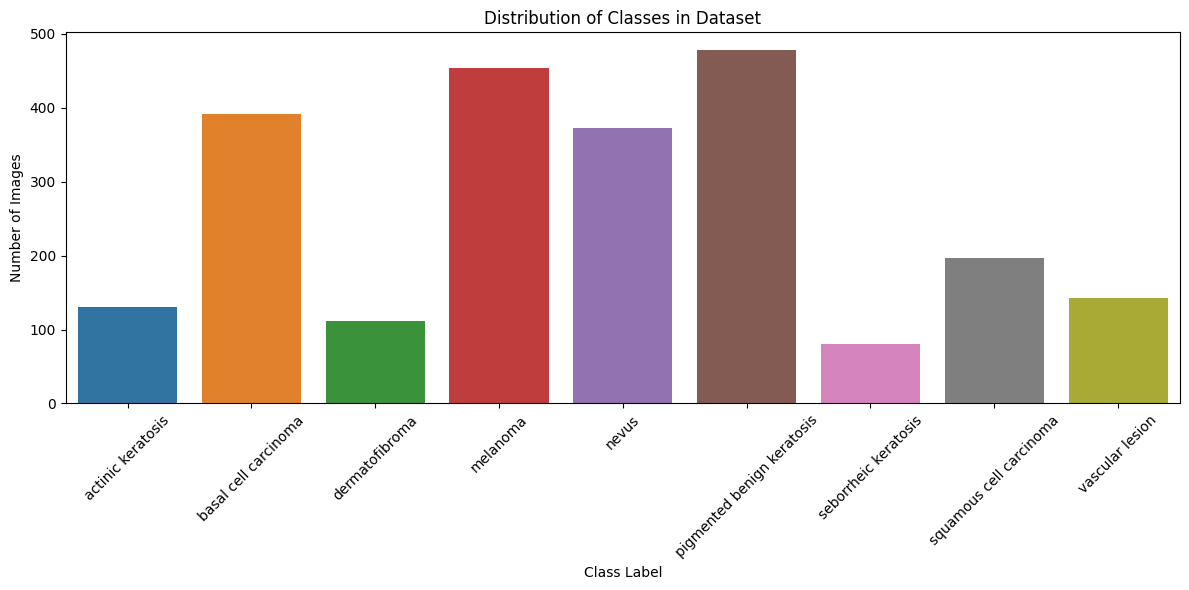

In [16]:
#Block 2

# Count the number of images in each class
class_counts = df['label'].value_counts().sort_index()

# Print the number of images in each class
print("Dataset Summary")
print("-" * 60)
print(f"{'Class Label':<15} {'Class Name':<30} {'Count':<10}")
print("-" * 60)
for class_label, class_name in label_map.items():
    count = class_counts[class_label]
    print(f"{class_label:<15} {class_name:<30} {count:<10}")
print("-" * 60)
print(f"{'Total':<45} {sum(class_counts):<10}")

# Plot class distribution
plt.figure(figsize=(12, 6))
sns.countplot(x='label', data=df)
plt.title('Distribution of Classes in Dataset')
plt.xlabel('Class Label')
plt.ylabel('Number of Images')
plt.xticks(ticks=range(num_classes), labels=[label_map[i] for i in range(num_classes)], rotation=45)
plt.tight_layout()
plt.show()

In [8]:
#Block 3

from PIL import Image
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import resample

# Define image size
IMG_HEIGHT = 75
IMG_WIDTH = 100

# Function to load and resize images
def load_and_resize_image(image_path):
    try:
        img = Image.open(image_path)
        img = img.resize((IMG_WIDTH, IMG_HEIGHT))
        return np.array(img)
    except Exception as e:
        print(f"Error loading {image_path}: {e}")
        return None

# Load all images
print("Loading images...")
df['image'] = df['image_path'].apply(load_and_resize_image)
df = df.dropna(subset=['image'])  # Remove failed loads
print(f"Successfully loaded {len(df)} images")

# Find the class with the maximum number of samples
max_class_size = df['label'].value_counts().max()
print(f"Majority class size: {max_class_size}")

# Create a balanced dataset by oversampling minority classes
balanced_dfs = []
for class_label in df['label'].unique():
    class_df = df[df['label'] == class_label]
    if len(class_df) < max_class_size:
        # Oversample minority classes
        oversampled_df = resample(class_df, 
                                 replace=True, 
                                 n_samples=max_class_size,
                                 random_state=42)
        balanced_dfs.append(oversampled_df)
    else:
        balanced_dfs.append(class_df)

# Combine balanced dataframes
balanced_df = pd.concat(balanced_dfs)
print(f"Balanced dataset size: {len(balanced_df)}")

# Verify new class distribution
print("\nBalanced Class Distribution:")
print(balanced_df['label'].value_counts().sort_index())

# Normalize pixel values
balanced_df['image'] = balanced_df['image'] / 255.0

# Create data augmentation generator
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

Loading images...
Successfully loaded 2357 images
Majority class size: 478
Balanced dataset size: 4302

Balanced Class Distribution:
label
0    478
1    478
2    478
3    478
4    478
5    478
6    478
7    478
8    478
Name: count, dtype: int64


In [17]:
#Block 4

from sklearn.model_selection import train_test_split
import tensorflow as tf

# Prepare data for splitting
x = np.stack(balanced_df['image'].values)
y = balanced_df['label'].values

# Convert labels to one-hot encoding
y_onehot = tf.keras.utils.to_categorical(y, num_classes=num_classes)

# Split into train (70%), validation (15%), and test (15%)
x_train, x_temp, y_train, y_temp = train_test_split(
    x, y_onehot, 
    test_size=0.3, 
    stratify=y, 
    random_state=42
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, 
    test_size=0.5, 
    stratify=np.argmax(y_temp, axis=1), 
    random_state=42
)

# Print split information
print(f"Training set: {x_train.shape} - {len(y_train)} samples")
print(f"Validation set: {x_val.shape} - {len(y_val)} samples")
print(f"Test set: {x_test.shape} - {len(y_test)} samples")

# Verify class distribution in each split
def print_class_distribution(y_data, split_name):
    y_labels = np.argmax(y_data, axis=1)
    unique, counts = np.unique(y_labels, return_counts=True)
    print(f"\n{split_name} Class Distribution:")
    for label, count in zip(unique, counts):
        print(f"  Class {label} ({label_map[label]}): {count} samples")

print_class_distribution(y_train, "Training")
print_class_distribution(y_val, "Validation")
print_class_distribution(y_test, "Test")

Training set: (3011, 75, 100, 3) - 3011 samples
Validation set: (645, 75, 100, 3) - 645 samples
Test set: (646, 75, 100, 3) - 646 samples

Training Class Distribution:
  Class 0 (actinic keratosis): 335 samples
  Class 1 (basal cell carcinoma): 335 samples
  Class 2 (dermatofibroma): 334 samples
  Class 3 (melanoma): 334 samples
  Class 4 (nevus): 334 samples
  Class 5 (pigmented benign keratosis): 335 samples
  Class 6 (seborrheic keratosis): 334 samples
  Class 7 (squamous cell carcinoma): 335 samples
  Class 8 (vascular lesion): 335 samples

Validation Class Distribution:
  Class 0 (actinic keratosis): 71 samples
  Class 1 (basal cell carcinoma): 72 samples
  Class 2 (dermatofibroma): 72 samples
  Class 3 (melanoma): 72 samples
  Class 4 (nevus): 72 samples
  Class 5 (pigmented benign keratosis): 71 samples
  Class 6 (seborrheic keratosis): 72 samples
  Class 7 (squamous cell carcinoma): 71 samples
  Class 8 (vascular lesion): 72 samples

Test Class Distribution:
  Class 0 (actinic 

In [18]:
#Block 5

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model

def create_model(input_shape=(75, 100, 3), num_classes=9):
    # Define Input explicitly
    inputs = Input(shape=input_shape)
    
    # First convolutional block
    x = Conv2D(32, (3, 3), activation='relu', name="conv2d_0")(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    
    # Second convolutional block
    x = Conv2D(64, (3, 3), activation='relu', name="conv2d_1")(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    
    # Third convolutional block
    x = Conv2D(128, (3, 3), activation='relu', name="conv2d_2")(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    
    # Fourth convolutional block (The layer we will target for Grad-CAM)
    x = Conv2D(256, (3, 3), activation='relu', name="conv2d_3")(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    
    # Flatten and dense layers
    x = Flatten()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    # Create the functional model
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Instantiate and compile
model = create_model()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 75, 100, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_0 (Conv2D)               │ (None, 73, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 73, 98, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 36, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 34, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 34, 47, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 17, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 15, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 10, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 5, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │         4,617 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,444,041 (5.51 MB)

 Trainable params: 1,443,081 (5.50 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.2897 - loss: 3.0562
Epoch 1: val_accuracy improved from -inf to 0.11163, saving model to best_skin_cancer_model.h5
95/95 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - accuracy: 0.2903 - loss: 3.0502 - val_accuracy: 0.1116 - val_loss: 3.7883 - learning_rate: 0.0010
Epoch 2/30
91/95 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4734 - loss: 1.5305
Epoch 2: val_accuracy improved from 0.11163 to 0.11938, saving model to best_skin_cancer_model.h5
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4743 - loss: 1.5272 - val_accuracy: 0.1194 - val_loss: 3.7484 - learning_rate: 0.0010
Epoch 3/30
91/95 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5694 - loss: 1.2200
Epoch 3: val_accuracy improved from 0.11938 to 0.15194, saving model to best_skin_cancer_model.h5
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5694 - loss: 1.2198 - val_accuracy: 0.1519 - val_loss: 4.1476 - learning_rate: 0.0010
Epoch 4/30
91/95 ━━━━━━━━━━━━━━━━

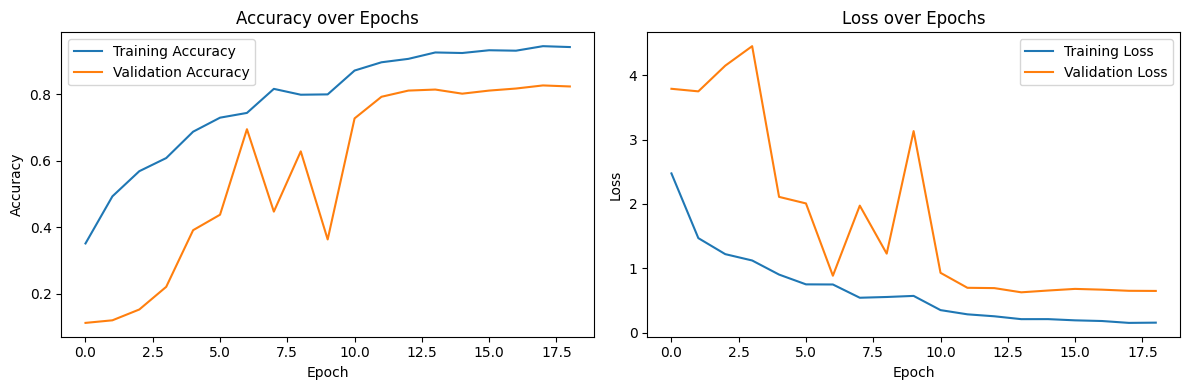

In [19]:
#Block 6

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Define callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_skin_cancer_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Train the model
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, model_checkpoint, reduce_lr],
    verbose=1
)

# Plot training history
def plot_history(history):
    plt.figure(figsize=(12, 4))
    
    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_history(history)

Test Accuracy: 0.8375
Test Loss: 0.5298
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step

Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       0.77      0.83      0.80        72
      basal cell carcinoma       0.85      0.82      0.83        71
            dermatofibroma       0.96      0.97      0.97        72
                  melanoma       0.71      0.72      0.72        72
                     nevus       0.78      0.75      0.77        72
pigmented benign keratosis       0.80      0.68      0.74        72
      seborrheic keratosis       0.83      0.82      0.83        72
   squamous cell carcinoma       0.88      0.94      0.91        72
           vascular lesion       0.93      1.00      0.97        71

                  accuracy                           0.84       646
                 macro avg       0.84      0.84      0.84       646
              weighted avg       0.84      0.84      0.84       646



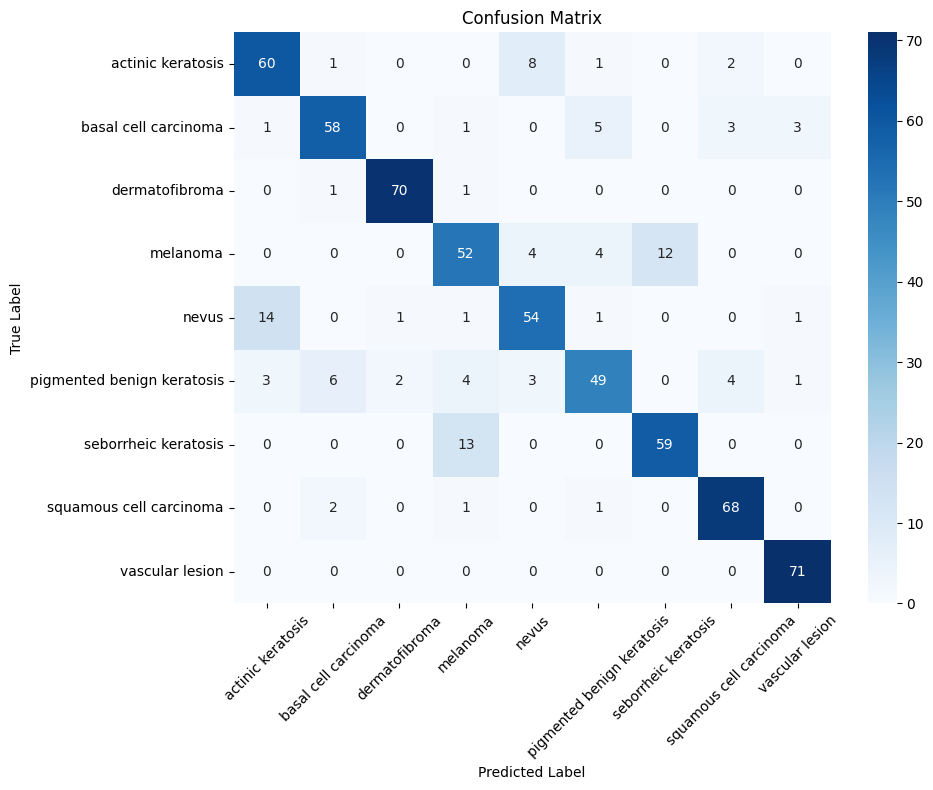

In [20]:
#Block 7

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# Load the best model
from tensorflow.keras.models import load_model
best_model = load_model('best_skin_cancer_model.h5')

# Evaluate on test set
test_loss, test_acc = best_model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Make predictions
y_pred = best_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=list(label_map.values())))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_map.values(), yticklabels=label_map.values())
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
#Block 8

# Load our best model (custom CNN)
best_model = load_model('best_skin_cancer_model.h5')

# Convert to TensorFlow Lite for mobile deployment
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)

# Apply quantization to reduce size and improve inference speed
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Optional: Further reduce size with float16 quantization
converter.target_spec.supported_types = [tf.float16]

# Convert the model
tflite_model = converter.convert()

# Save the TensorFlow Lite model
with open('sagalyze_model.tflite', 'wb') as f:
    f.write(tflite_model)

# Check model size
model_size = os.path.getsize('sagalyze_model.tflite') / (1024 * 1024)  # MB
print(f"Model Size: {model_size:.2f} MB")

# Test inference time
import time
interpreter = tf.lite.Interpreter(model_path='sagalyze_model.tflite')
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Test with a sample image
sample_image = np.expand_dims(x_test[0], axis=0).astype('float32')
interpreter.set_tensor(input_details[0]['index'], sample_image)

# Measure inference time
start_time = time.time()
interpreter.invoke()
inference_time = time.time() - start_time

print(f"Inference Time: {inference_time:.4f} seconds")

# Get prediction
prediction = interpreter.get_tensor(output_details[0]['index'])
predicted_class = np.argmax(prediction)
print(f"Predicted Class: {predicted_class} ({label_map[predicted_class]})")
print(f"Actual Class: {np.argmax(y_test[0])} ({label_map[np.argmax(y_test[0])]})")

# Verify model performance on test set
# Fix the evaluation function - convert input to FLOAT32
def evaluate_tflite_model(interpreter, x_test, y_test):
    correct_predictions = 0
    total_predictions = len(x_test)
    
    for i in range(total_predictions):
        # Convert input to FLOAT32 and add batch dimension
        input_data = np.expand_dims(x_test[i], axis=0).astype(np.float32)
        
        # Set input
        interpreter.set_tensor(input_details[0]['index'], input_data)
        
        # Run inference
        interpreter.invoke()
        
        # Get prediction
        prediction = interpreter.get_tensor(output_details[0]['index'])
        predicted_class = np.argmax(prediction)
        actual_class = np.argmax(y_test[i])
        
        if predicted_class == actual_class:
            correct_predictions += 1
    
    accuracy = correct_predictions / total_predictions
    return accuracy

Saved artifact at '/tmp/tmpwi_sgwsu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 75, 100, 3), dtype=tf.float32, name='input_layer_4')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  140317728023248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140317728021712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140316056986320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140316056986128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140316056986512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140316056985168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140316056988624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140316056986896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140313428322896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140313428326736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14031342832424

W0000 00:00:1771672064.900637      38 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1771672064.900664      38 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


Generating Explanations...
Generating LIME...


The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_4']]
Received: inputs=Tensor(shape=(1, 75, 100, 3))


  0%|          | 0/200 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


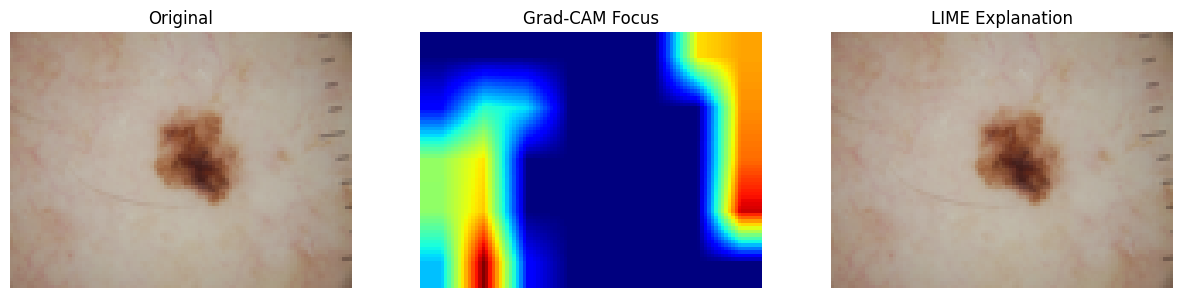

In [34]:
#Block 9

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
from lime import lime_image

# 1. Select Image and ensure it is a Float32 Tensor for the model
idx = 0
sample_image = x_test[idx].astype('float32')
# Explicitly convert to a TensorFlow tensor to avoid structure mismatch
img_batch = tf.convert_to_tensor(np.expand_dims(sample_image, axis=0))

# 2. Corrected Native Grad-CAM
def get_gradcam(model, img, layer_name):
    # Create a sub-model to get gradients
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img)
        # Find the index of the highest predicted class
        pred_idx = tf.argmax(predictions[0])
        loss = predictions[:, pred_idx]
    
    # Calculate gradients
    output = conv_outputs[0]
    grads = tape.gradient(loss, conv_outputs)[0]
    
    # Weight the channels by the gradient values
    gate_f = tf.reduce_mean(grads, axis=(0, 1))
    
    # Create the heatmap
    cam = tf.reduce_sum(tf.multiply(gate_f, output), axis=-1)
    
    # Convert to Numpy and Post-process
    cam = cam.numpy() # Convert the tensor to numpy here
    cam = np.maximum(cam, 0)
    
    # Safety check for division by zero
    if np.max(cam) != 0:
        cam = (cam - cam.min()) / (cam.max() - cam.min())
        
    cam = cv2.resize(cam, (100, 75)) # cam is now a numpy array, no .numpy() needed
    return cam

print("Generating Explanations...")

# Generate Heatmap
heatmap = get_gradcam(best_model, img_batch, "conv2d_3")

# 3. LIME
print("Generating LIME...")
explainer = lime_image.LimeImageExplainer()
# LIME needs a standard numpy array, so we use sample_image.astype('double')
explanation = explainer.explain_instance(
    sample_image.astype('double'), 
    best_model.predict, 
    top_labels=1, 
    num_samples=200
)
lime_img, mask = explanation.get_image_and_mask(
    explanation.top_labels[0], 
    positive_only=True, 
    num_features=5, 
    hide_rest=False
)

# 4. Plot
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(sample_image)
plt.title("Original")
plt.axis('off')

plt.subplot(1, 3, 2)
# Using 'jet' color map for better medical visualization
plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM Focus")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(lime_img)
plt.title("LIME Explanation")
plt.axis('off')

plt.show()

The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_4']
Received: inputs=Tensor(shape=(1, 75, 100, 3))


  0%|          | 0/250 [00:00<?, ?it/s]

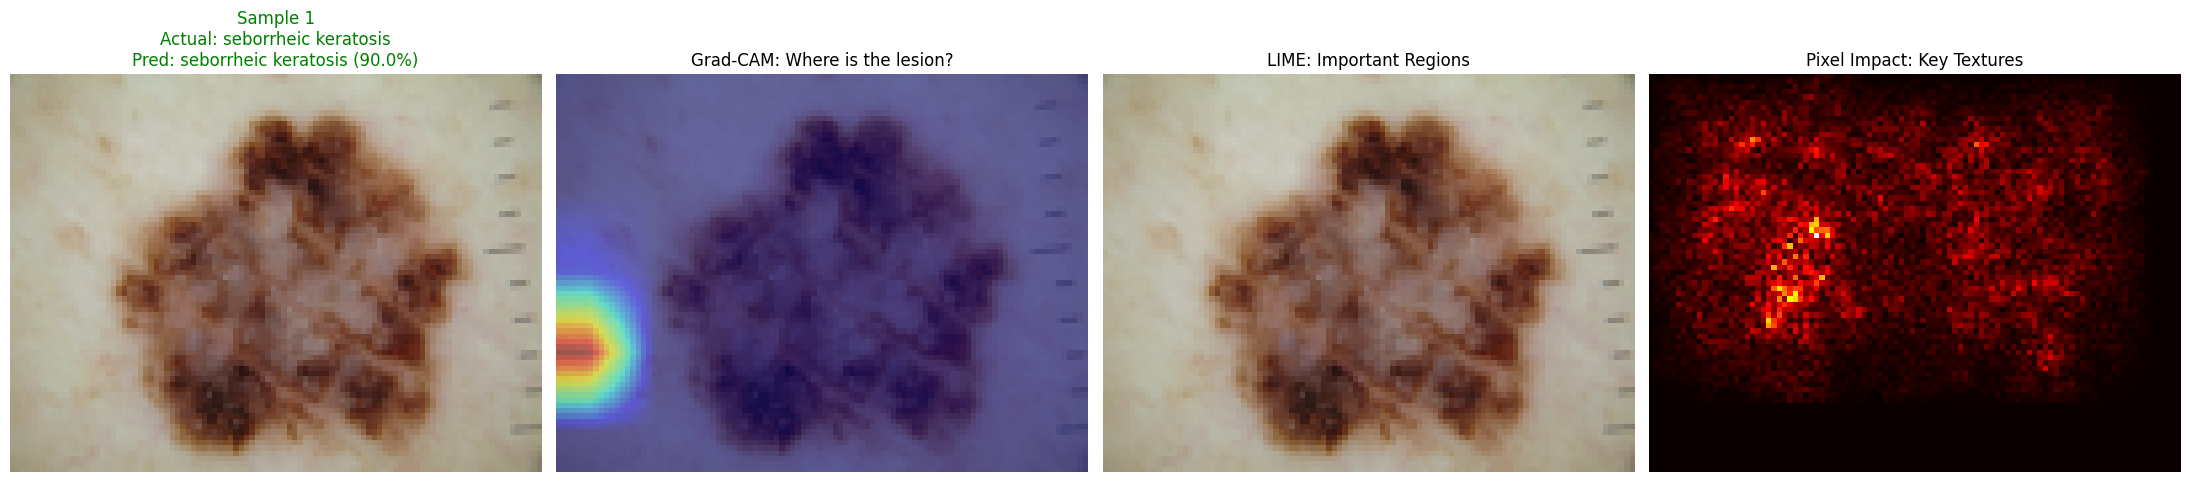

The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_4']
Received: inputs=Tensor(shape=(1, 75, 100, 3))


  0%|          | 0/250 [00:00<?, ?it/s]

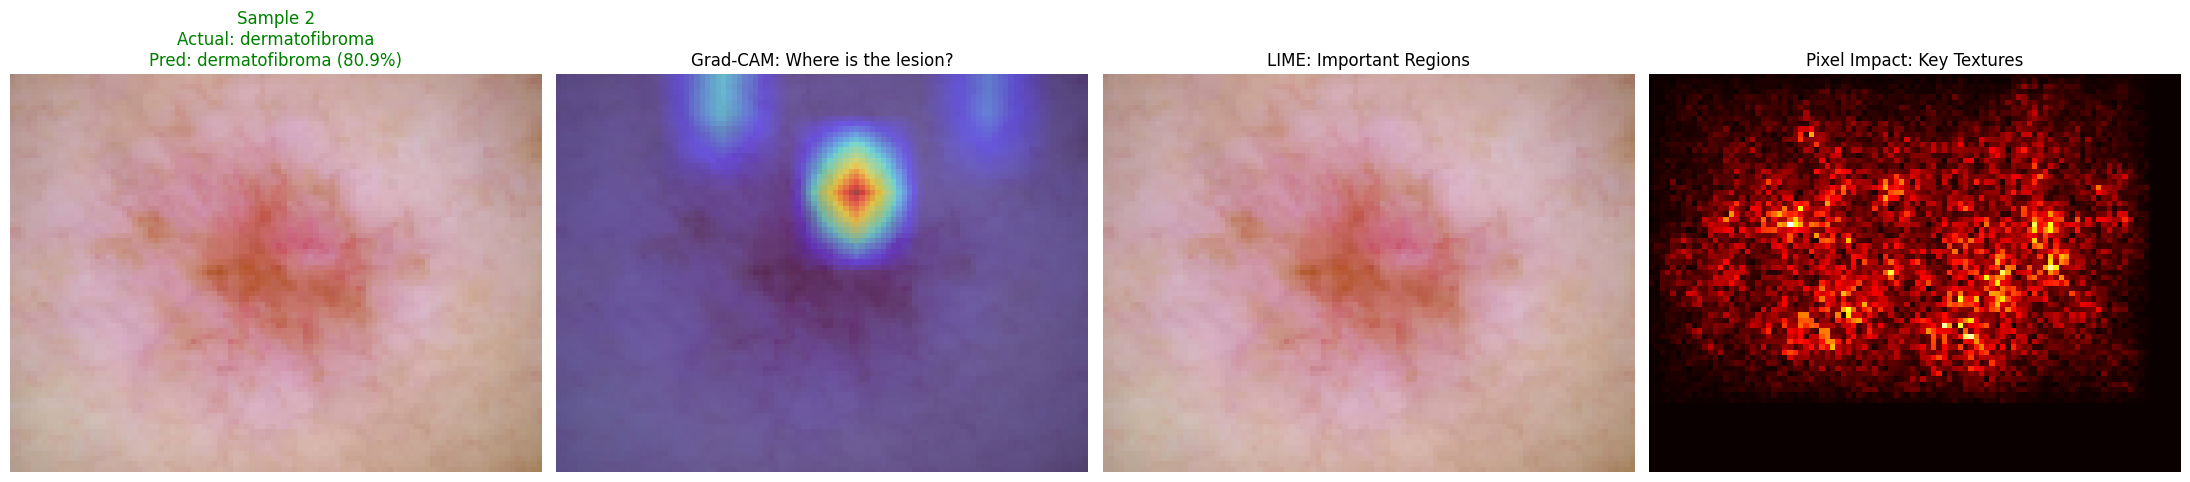

The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_4']
Received: inputs=Tensor(shape=(1, 75, 100, 3))


  0%|          | 0/250 [00:00<?, ?it/s]

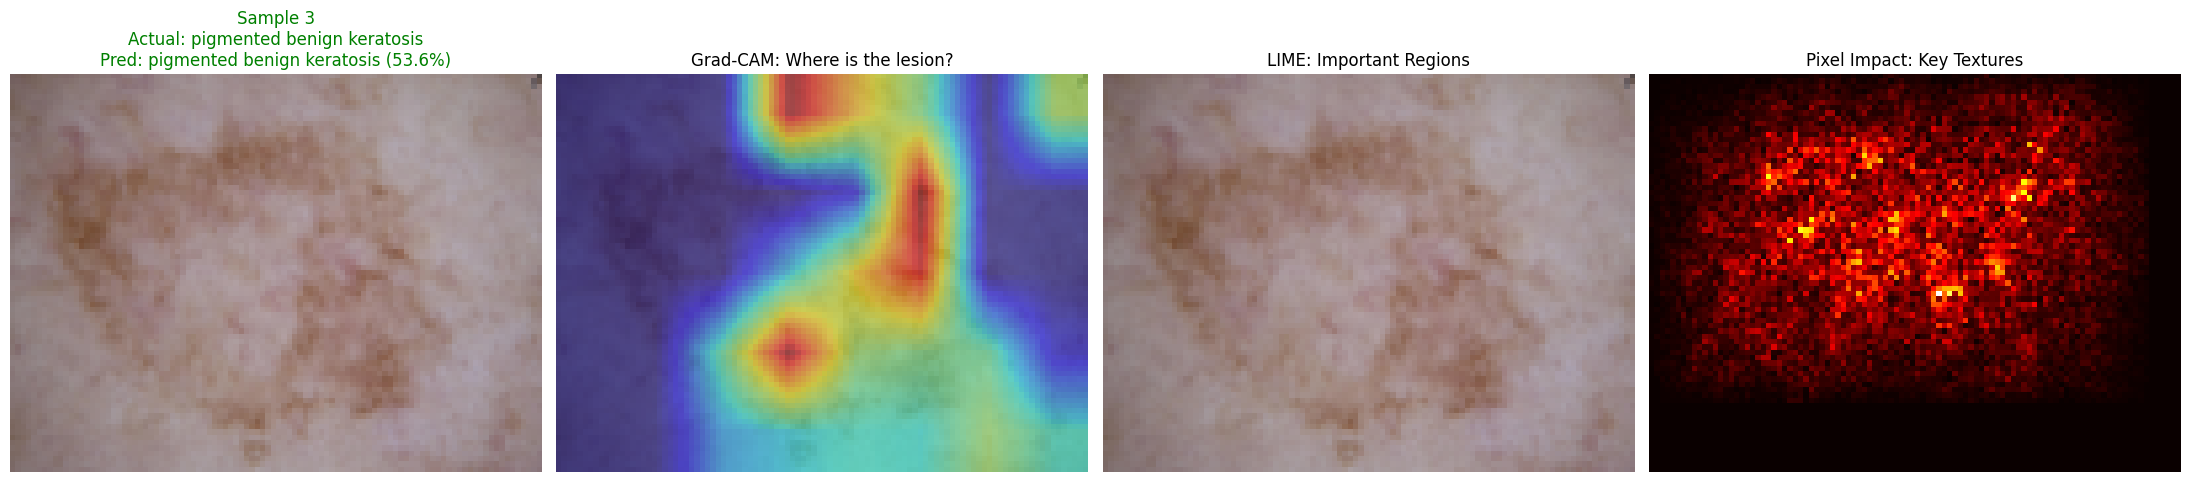

The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_4']
Received: inputs=Tensor(shape=(1, 75, 100, 3))


  0%|          | 0/250 [00:00<?, ?it/s]

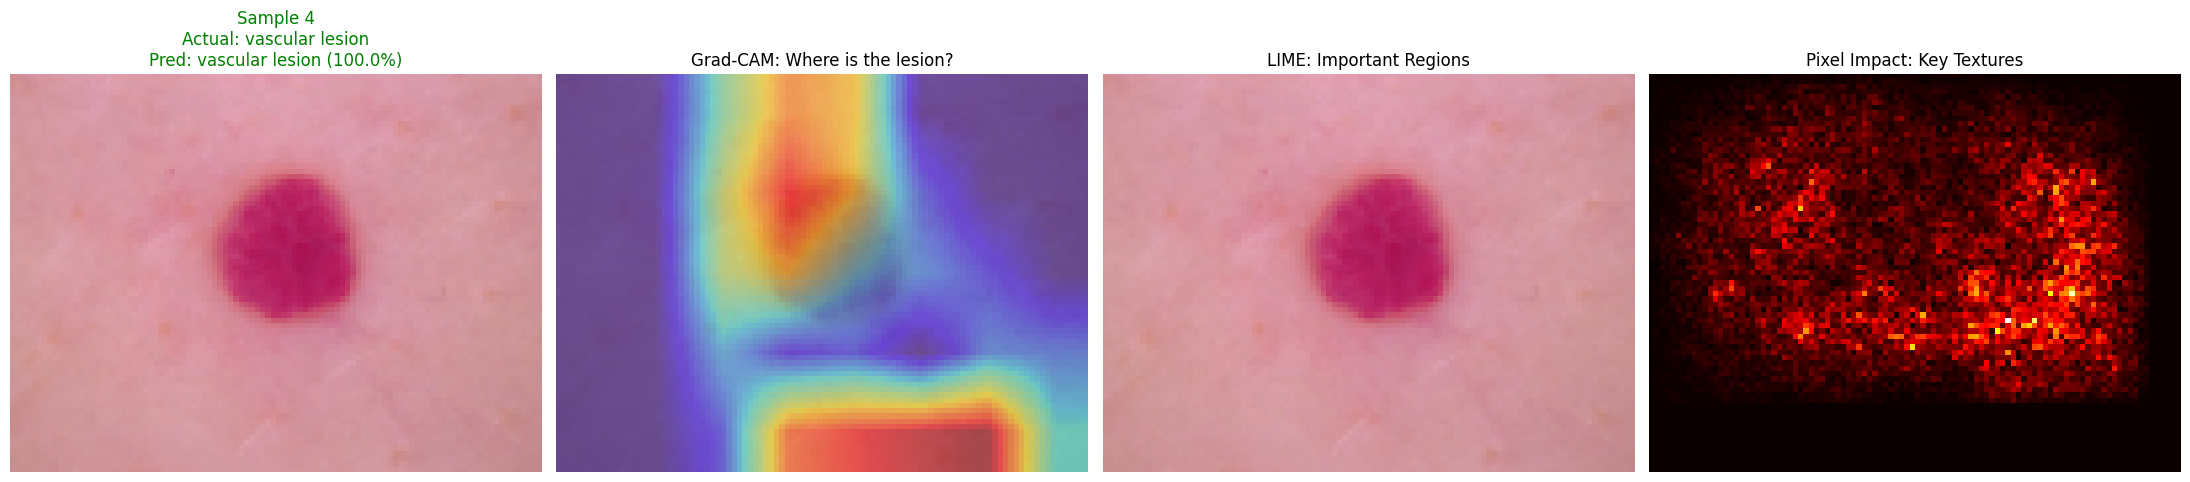

The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_4']
Received: inputs=Tensor(shape=(1, 75, 100, 3))


  0%|          | 0/250 [00:00<?, ?it/s]

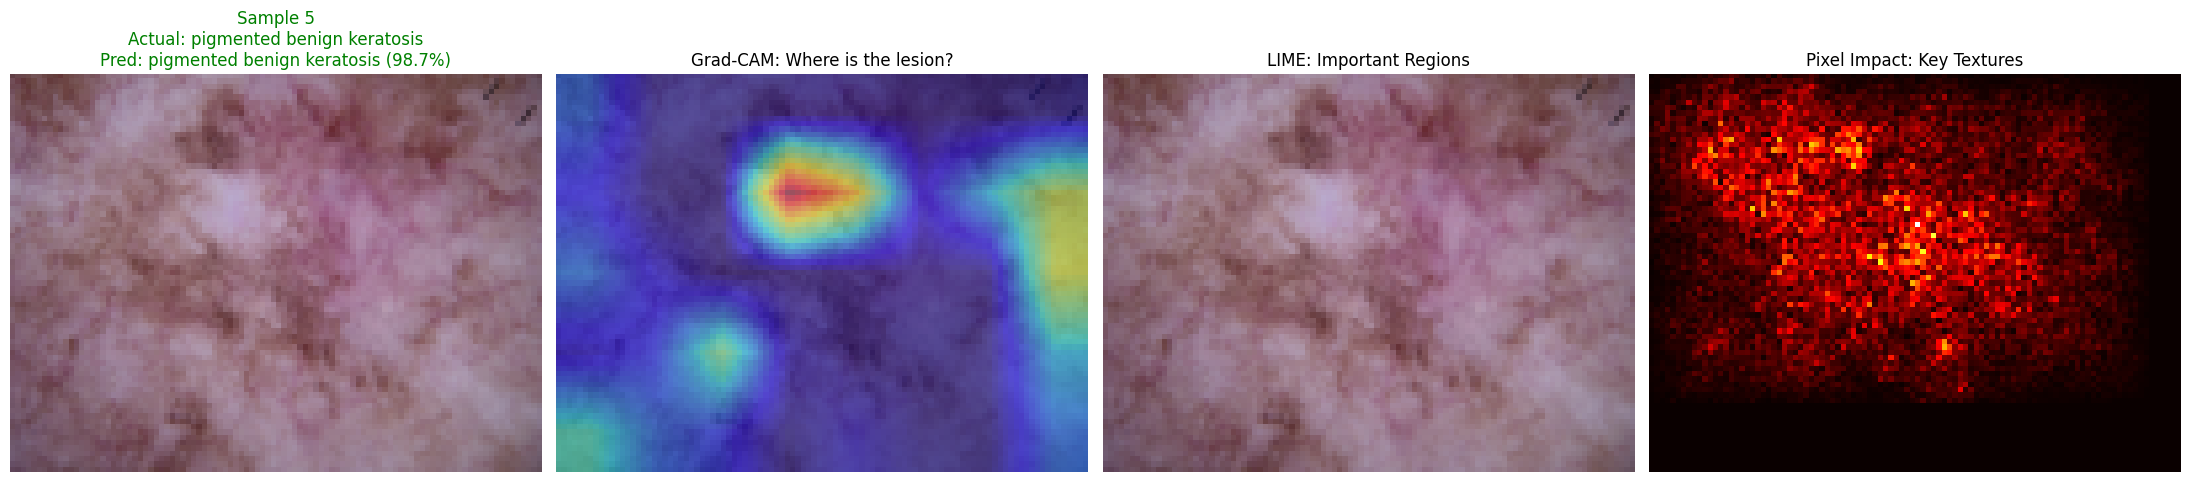

In [37]:
#Block 11

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
from lime import lime_image
import random

# --- 1. ROBUST XAI FUNCTIONS ---

def get_gradcam_verified(model, img_array, layer_name):
    """Grad-CAM that respects Keras 3 Functional API input names."""
    # Create a sub-model that outputs both the target conv layer and the final prediction
    grad_model = tf.keras.models.Model(
        inputs=model.inputs, 
        outputs=[model.get_layer(layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        # Pass img_array directly (shape: 1, 75, 100, 3) to match 'input_layer_2'
        conv_outputs, predictions = grad_model(img_array, training=False)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    # Compute gradients of the loss with respect to the convolutional output
    grads = tape.gradient(loss, conv_outputs)[0]
    output = conv_outputs[0]
    
    # Global average pooling of gradients
    weights = tf.reduce_mean(grads, axis=(0, 1))
    cam = tf.reduce_sum(tf.multiply(weights, output), axis=-1).numpy()
    
    # Visibility Fix: Apply ReLU and Normalize
    cam = np.maximum(cam, 0)
    if np.max(cam) > 0:
        cam = cam / np.max(cam)
    else:
        # Fallback if gradients are zero (extremely confident model)
        cam = np.zeros(cam.shape)
        
    return cv2.resize(cam, (100, 75))

def get_pixel_impact_map(model, img_array, pred_idx):
    """A direct SHAP alternative using Gradient Attribution."""
    img_tensor = tf.convert_to_tensor(img_array)
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        # Call model directly to satisfy Keras 3 signature
        preds = model(img_tensor, training=False)
        target_score = preds[:, pred_idx]
    
    # Calculate gradients of the predicted class with respect to raw pixels
    grads = tape.gradient(target_score, img_tensor)
    # Sum absolute values across RGB channels for impact visualization
    impact_map = tf.reduce_sum(tf.abs(grads), axis=-1)[0].numpy()
    
    # Normalize for high-contrast visibility
    if np.max(impact_map) > 0:
        impact_map = impact_map / np.max(impact_map)
    return impact_map

# --- 2. EXECUTION LOOP ---

# Select 5 samples for verification
sample_indices = random.sample(range(len(x_test)), 5)

for i, idx in enumerate(sample_indices):
    # 1. Prepare image for prediction (shape: 1, 75, 100, 3)
    sample_image = x_test[idx].astype('float32')
    img_input = np.expand_dims(sample_image, axis=0) 
    
    # 2. Get Model Prediction
    # Pass the array directly, NOT in a list [img_input]
    preds = best_model.predict(img_input, verbose=0)
    pred_idx = np.argmax(preds[0])
    actual_idx = np.argmax(y_test[idx])
    confidence = preds[0][pred_idx] * 100
    
    # 3. Generate Interpretability Maps
    # Grad-CAM
    try:
        heatmap = get_gradcam_verified(best_model, img_input, "conv2d_3")
    except:
        heatmap = np.zeros((75, 100)) # Fallback if layer name differs

    # LIME
    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        sample_image.astype('double'), 
        lambda x: best_model.predict(x, verbose=0),
        top_labels=1, 
        num_samples=250 # Increased for better stability
    )
    lime_img, _ = explanation.get_image_and_mask(
        explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
    )

    # Pixel Impact (SHAP Replacement)
    impact_map = get_pixel_impact_map(best_model, img_input, pred_idx)

    # --- 4. VISUALIZATION ---
    plt.figure(figsize=(22, 5))
    
    # Column 1: Original + Prediction
    plt.subplot(1, 4, 1)
    plt.imshow(sample_image)
    color = 'green' if pred_idx == actual_idx else 'red'
    plt.title(f"Sample {i+1}\nActual: {label_map[actual_idx]}\nPred: {label_map[pred_idx]} ({confidence:.1f}%)", color=color)
    plt.axis('off')

    # Column 2: Grad-CAM (Global Focus)
    plt.subplot(1, 4, 2)
    plt.imshow(sample_image)
    plt.imshow(heatmap, cmap='jet', alpha=0.5)
    plt.title("Grad-CAM: Where is the lesion?")
    plt.axis('off')

    # Column 3: LIME (Local Features)
    plt.subplot(1, 4, 3)
    plt.imshow(lime_img)
    plt.title("LIME: Important Regions")
    plt.axis('off')
    
    # Column 4: Impact Map (Granular Detail)
    plt.subplot(1, 4, 4)
    # Using 'hot' colormap to see faint signals better
    plt.imshow(impact_map, cmap='hot')
    plt.title("Pixel Impact: Key Textures")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
pip install shap lime tf-explain

✅ Success! Graphs saved as 'Final_Research_Paper_Graphs.png' in /kaggle/working/


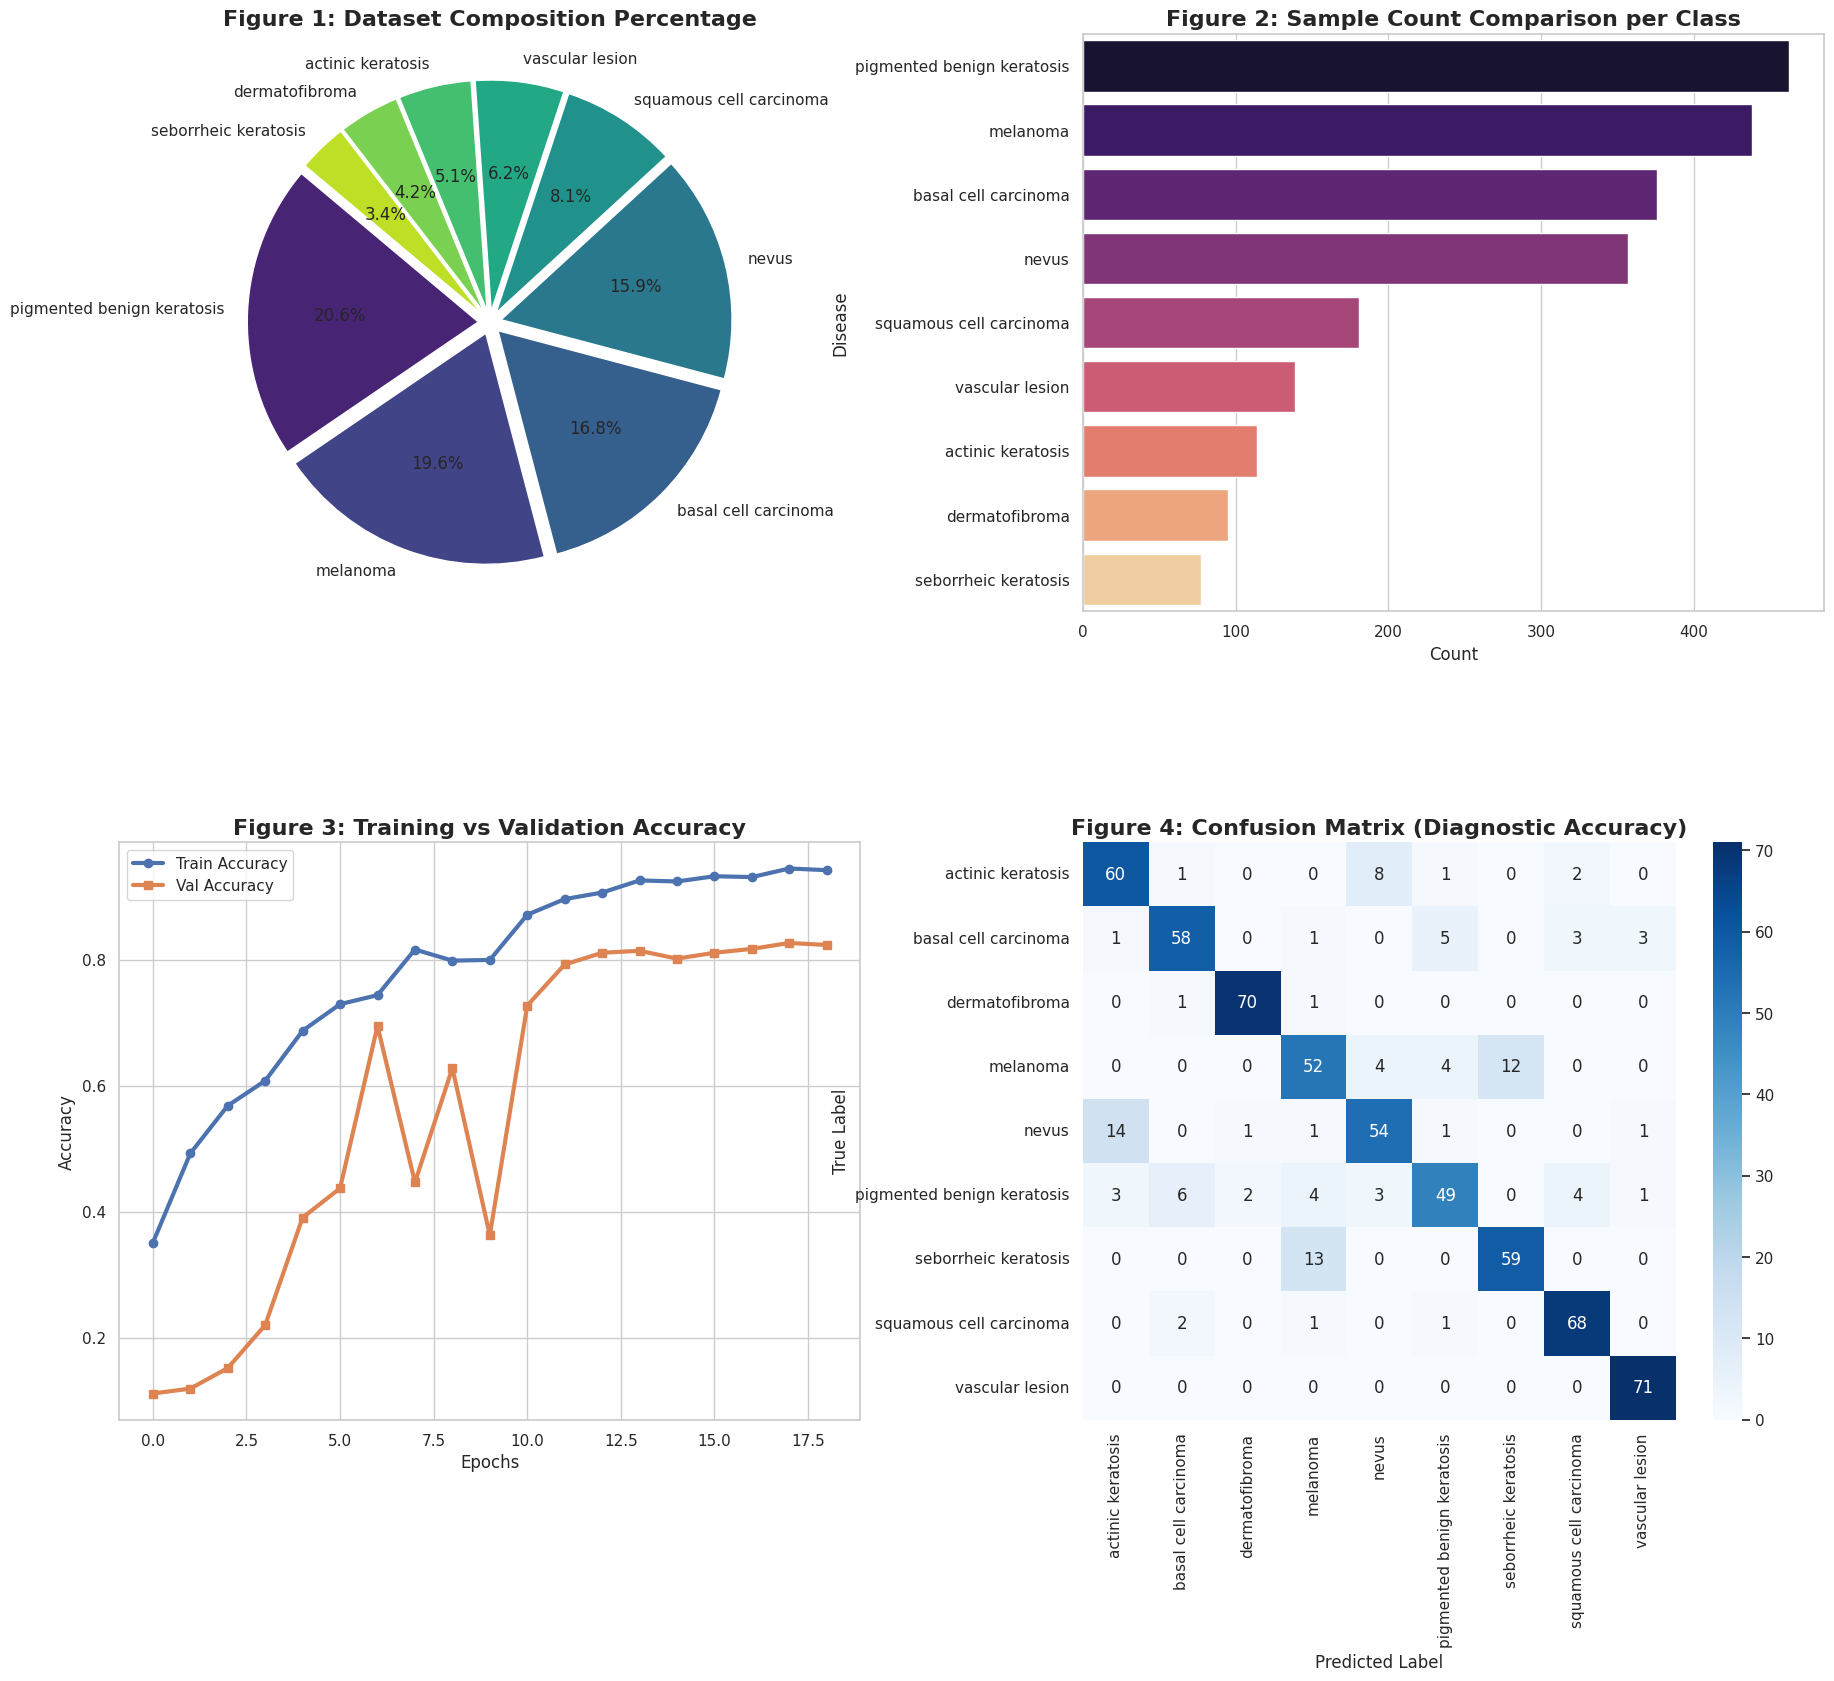

In [45]:
# ==============================================================================
# FINAL CONSOLIDATED RESEARCH VISUALIZATIONS (FIXED VERSION)
# ==============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. DATA PREPARATION
train_dir = '/kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train'
class_names = sorted(os.listdir(train_dir))
counts = [len(os.listdir(os.path.join(train_dir, c))) for c in class_names]
df_dist = pd.DataFrame({'Disease': class_names, 'Count': counts}).sort_values('Count', ascending=False)

# 2. SETUP FIGURE
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(22, 18))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- PLOT 1: PIE CHART (Data Distribution) ---
axes[0, 0].pie(df_dist['Count'], labels=df_dist['Disease'], autopct='%1.1f%%', 
              startangle=140, colors=sns.color_palette("viridis", len(class_names)),
              explode=[0.05]*len(class_names))
axes[0, 0].set_title('Figure 1: Dataset Composition Percentage', fontsize=16, fontweight='bold')

# --- PLOT 2: COMPARISON BAR CHART (Class Counts) ---
sns.barplot(ax=axes[0, 1], x='Count', y='Disease', data=df_dist, palette='magma')
axes[0, 1].set_title('Figure 2: Sample Count Comparison per Class', fontsize=16, fontweight='bold')

# --- PLOT 3: MODEL PERFORMANCE (Accuracy/Loss) ---
if 'history' in globals():
    axes[1, 0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=3, marker='o')
    axes[1, 0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=3, marker='s')
    axes[1, 0].set_title('Figure 3: Training vs Validation Accuracy', fontsize=16, fontweight='bold')
    axes[1, 0].set_xlabel('Epochs')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].legend()
else:
    axes[1, 0].text(0.5, 0.5, 'Run Model Training First', ha='center', va='center', fontsize=14, color='red')

# --- PLOT 4: CONFUSION MATRIX (FIXED) ---
if 'y_test' in globals() and 'y_pred_classes' in globals():
    # FIX: Convert y_test from One-Hot to Integer if necessary
    y_true_clean = y_test
    if len(y_test.shape) > 1 and y_test.shape[1] > 1:
        y_true_clean = np.argmax(y_test, axis=1)
        
    cm = confusion_matrix(y_true_clean, y_pred_classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1],
                xticklabels=class_names, yticklabels=class_names)
    axes[1, 1].set_title('Figure 4: Confusion Matrix (Diagnostic Accuracy)', fontsize=16, fontweight='bold')
    axes[1, 1].set_xlabel('Predicted Label')
    axes[1, 1].set_ylabel('True Label')
else:
    axes[1, 1].text(0.5, 0.5, 'Run Evaluation First', ha='center', va='center', fontsize=14, color='red')

# 3. SAVE TO KAGGLE DIRECTORY
plt.savefig('Final_Research_Paper_Graphs.png', dpi=300, bbox_inches='tight')
print("✅ Success! Graphs saved as 'Final_Research_Paper_Graphs.png' in /kaggle/working/")
plt.show()

In [47]:
import os
import zipfile

# Define the name of your download file
zip_name = 'skin_disease_project_all_files.zip'
directory_to_zip = '/kaggle/working'

# Use zipfile.ZIP_DEFLATED (calling the module, not the string)
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(directory_to_zip):
        for file in files:
            # Avoid zipping the zip file itself
            if file != zip_name:
                file_path = os.path.join(root, file)
                # Add file to zip
                zipf.write(file_path, arcname=os.path.relpath(file_path, directory_to_zip))

print(f"Success! All files are zipped into: {zip_name}")
print("Go to the 'Data' pane on the right -> 'Output' -> '/kaggle/working' to download it.")

Success! All files are zipped into: skin_disease_project_all_files.zip
Go to the 'Data' pane on the right -> 'Output' -> '/kaggle/working' to download it.
